# Project 1 — Regression, resampling methods and gradient descent

**FYS-STK3155/4155**, University of Oslo, autumn 2026
**Parisa Amin**

We study polynomial regression on Runge's function

$$f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1],$$

with ordinary least squares, Ridge and Lasso; the bootstrap and $k$-fold
cross-validation; and gradient-descent optimisers.

Reusable functions live in `regression.py`; this notebook runs the experiments.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# pick up edits to regression.py without restarting the kernel
%load_ext autoreload
%autoreload 2

from regression import (runge, make_data, polynomial_features, MSE, R2, ols, fit_predict,
                        BLUE, RED, YELLOW, GREY, GREEN)

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
# Part a) Ordinary Least Squares

**Goal:** build the machinery, and see overfitting happen — training MSE falling
for ever while test MSE turns back up, driven by coefficients that explode.

## a.1 The data

Generate Runge data on $[-1,1]$ with noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$,
$\sigma = 0.1$. Plot the noisy samples against the true function to check it looks right.

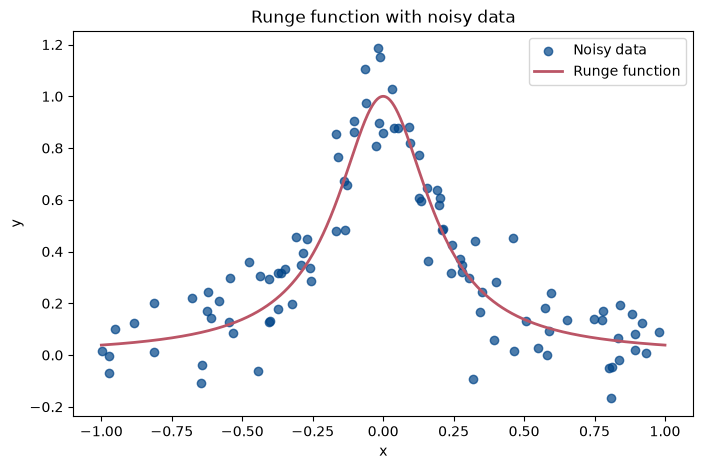

In [43]:
x , y= make_data(n= 100 , sigma= 0.1 , seed= 2026)
x_fine = np.linspace(-1,1, 1000)
y_fine = runge(x_fine)


plt.figure(figsize=(8,5))
plt.scatter(x,y, label= "Noisy data" , color= BLUE , alpha= 0.7)
plt.plot(x_fine , y_fine , label= "Runge function" , color= RED , linewidth= 2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge function with noisy data")
plt.legend()

plt.show()


## a.2 Train/test split and scaling

Split roughly 80/20. Then **centre `y` and standardise the feature columns —
fitting the scaler on the training data only**, and applying those same numbers to
the test data.

Why it matters: if the scaler sees the test set, information has leaked from test
into train and your error estimate is optimistically biased. The project asks for a
critical discussion of this, so write down what you did and why.

In [44]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2 , random_state= 2026)

print(len(x_test))
print(len(x_train))


20
80


## a.3 MSE and $R^2$ against polynomial degree

For degree $= 1 \ldots 15$: build the design matrix, fit OLS, record training and
test MSE and $R^2$.

Expect: training MSE falls monotonically; test MSE falls then rises. Use a log
scale on the MSE axis and mark the noise floor $\sigma^2$ with a grey dashed line —
no model can do better than that.

In [45]:
print(x_train.shape)
print(x_train.ndim)

(80,)
1


In [46]:

# x = raw input vector, X = polynomial design matrix
degrees = np.arange(1, 16)

#print(degrees)

mse_train= np.zeros(len(degrees))
mse_test= np.zeros(len(degrees))

r2_train= np.zeros(len(degrees))
r2_test= np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)
    X_test= polynomial_features(x_test, degree)

    X_mean= np.mean(X_train, axis=0)  #capital X
    X_std= np.std(X_train, axis=0)    #capital X

    X_train_scaled= (X_train - X_mean)/X_std
    X_test_scaled= (X_test - X_mean)/ X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta= ols(X_train_scaled, y_train_centered)

    y_train_pred = X_train_scaled @ theta + y_mean
    y_test_pred = X_test_scaled @ theta + y_mean


    mse_train[i]= MSE(y_train, y_train_pred)
    mse_test[i]= MSE(y_test, y_test_pred)

    r2_train[i]= R2(y_train, y_train_pred)
    r2_test[i]= R2(y_test, y_test_pred) 

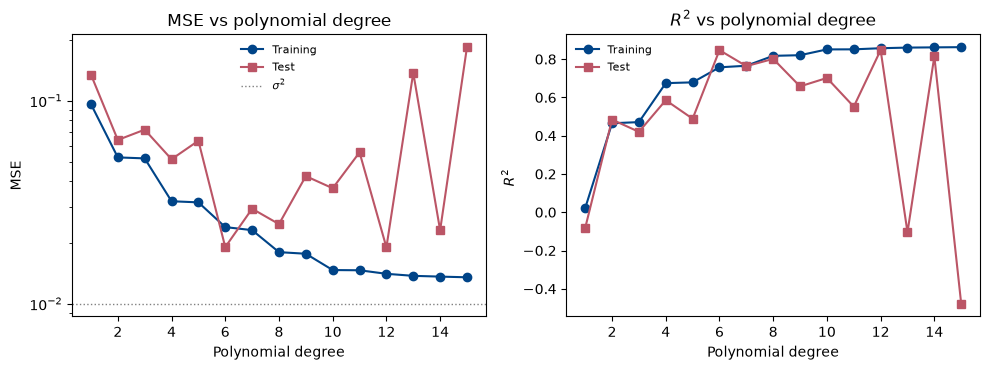

In [47]:
plt.figure(figsize=(10, 3.8))

#MSE plot
plt.subplot(1, 2, 1)

plt.plot(degrees, mse_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, mse_test, "s-",color=RED, label="Test")

plt.yscale("log")                                      # MSE panel only
plt.axhline(0.1**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("MSE vs polynomial degree")
plt.legend(frameon=False, fontsize=8)

#R2 plot
plt.subplot(1, 2, 2)

plt.plot(degrees, r2_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, r2_test,"s-", color=RED, label="Test")

plt.xlabel("Polynomial degree")
plt.ylabel( r"$R^2$ " )
plt.title( r"$R^2$ vs polynomial degree")
plt.legend(frameon=False, fontsize=8)


plt.tight_layout()
plt.savefig("../results/a3_mse_r2.pdf", bbox_inches="tight")
plt.show()


## a.4 The coefficients $\theta$ against degree

This is the figure that explains the U-shape. Plot the magnitude of the fitted
coefficients as the degree grows — expect them to reach enormous values with
alternating signs, because the design matrix becomes nearly singular and the fit
relies on huge cancelling terms.

A log scale on $|\theta_j|$ makes it readable.

In [48]:
 # a.4 — how the coefficients grow with degree

theta_all = []
max_theta = np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)

    X_mean= np.mean(X_train, axis=0)
    X_std = np.std(X_train, axis=0)

    X_train_scaled= (X_train - X_mean) / X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta = ols(X_train_scaled, y_train_centered)
    theta_all.append(theta)

    max_theta[i] = np.max(np.abs(theta))



In [49]:
#print(max_theta)
print(theta_all[5])

print(max_theta[5])

[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]
2.1178573485608494


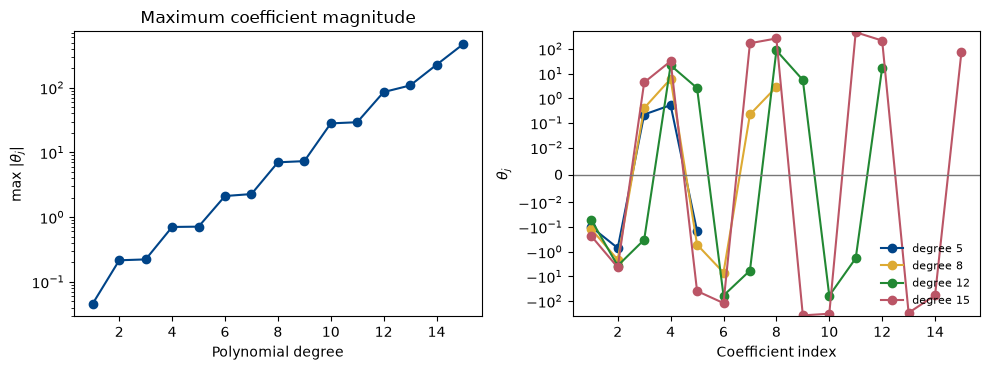

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))


##Left panel

axes[0].semilogy(degrees, max_theta, "o-", color=BLUE )

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel(r"max $|\theta_j|$")
axes[0].set_title("Maximum coefficient magnitude")


## Right panel
for degree, c in zip([5, 8, 12, 15], [BLUE, YELLOW, GREEN, RED]):
    theta = theta_all[degree - 1]
    j = np.arange(1, degree + 1)
    axes[1].plot(j, theta, "o-", color=c, label=f"degree {degree}")



axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel(r"$\theta_j$")
axes[1].legend(frameon= False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/a4_theta.pdf", bbox_inches="tight")
plt.show()




## a.5 Dependence on the number of points and the noise level

Repeat the degree sweep for a few values of $n$ and of $\sigma$.

Expect: more data supports a higher degree before overfitting sets in; more noise
pushes the optimal degree down.

In [51]:
# Different number of points
degrees = np.arange(1, 16)
n_values = [50, 100, 200, 1000]
sigma_fixed= 0.1

mse_by_n= {}


for n in n_values:

    #Generate new data set
    x_n , y_n = make_data(n=n, sigma=sigma_fixed, seed=2026)

    #split and test
    x_train_n, x_test_n, y_train_n , y_test_n = train_test_split(x_n, y_n, test_size= 0.2, random_state=2026)

     # One MSE value for each degree
    mse_test_n = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_n, x_test_n, y_train_n, degree)

        mse_test_n[i] = MSE(y_test_n, y_test_pred)


    mse_by_n[n] = mse_test_n



In [52]:
sigma_values = [0.01, 0.1, 0.3]
n_fixed = 100

mse_by_sigma = {}

for sigma in sigma_values:
    #Generate new data set
    x_s , y_s = make_data(n=n_fixed, sigma=sigma, seed=2026)

    #split and test
    x_train_s, x_test_s, y_train_s , y_test_s = train_test_split(x_s, y_s, test_size= 0.2, random_state=2026)


    # Store test MSE for all degrees
    mse_test_s = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_s, x_test_s, y_train_s, degree)

        mse_test_s[i] = MSE(y_test_s, y_test_pred)


    mse_by_sigma[sigma] = mse_test_s

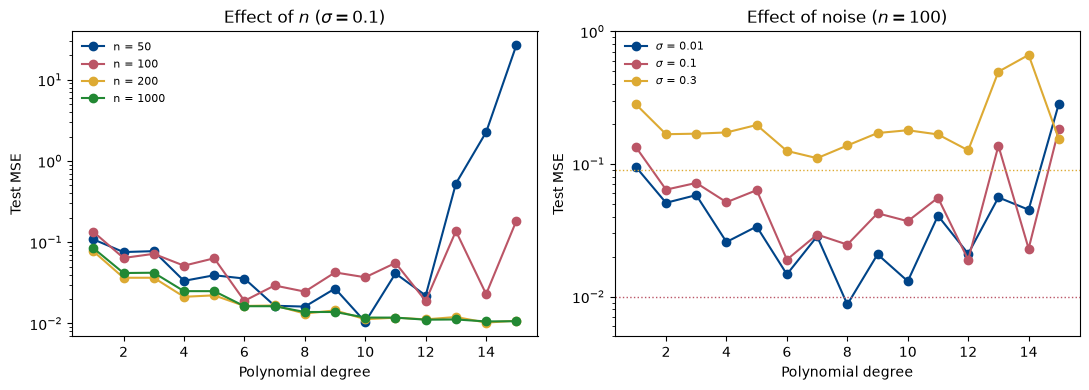

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = [BLUE, RED, YELLOW, GREEN]

  
# --------------------------------------------------
# Left panel: different n
# --------------------------------------------------

for i, n in enumerate(n_values):

      axes[0].semilogy(degrees, mse_by_n[n], "o-", color=colors[i], label=f"n = {n}")

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("Test MSE")
axes[0].set_title(r"Effect of $n$ ($\sigma=0.1$)")
axes[0].legend(frameon=False, fontsize=8)


# --------------------------------------------------
# Right panel: different sigma
# --------------------------------------------------

for i, sigma in enumerate(sigma_values):

    axes[1].semilogy(degrees, mse_by_sigma[sigma], "o-", color=colors[i], label=fr"$\sigma$ = {sigma}")
  
    axes[1].axhline(sigma**2, color=colors[i], linestyle=":", linewidth=1)
  
axes[1].set_ylim(5e-3, 1)
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("Test MSE")
axes[1].set_title(r"Effect of noise ($n=100$)")
axes[1].legend(frameon=False, fontsize=8)

 
plt.tight_layout()
plt.savefig("../results/a5_n_sigma.pdf", bbox_inches="tight")
plt.show()
  


---
# Part b) Ridge regression

**Goal:** control the explosion. Ridge minimises

$$C(\theta) = \frac{1}{n}\lVert X\theta - y \rVert^2 + \lambda\lVert\theta\rVert^2,
\qquad
\theta = (X^TX + n\lambda I)^{-1}X^Ty.$$

**The factor $n$ comes from the $1/n$ in the cost function — don't drop it.**

## b.1 Implement Ridge, and benchmark it

Add `ridge(X, y, lam)` to `regression.py`, then check it two ways:

1. `lam = 0` must reproduce your OLS result exactly
2. it must match `Ridge(alpha=n*lam, fit_intercept=False)` from scikit-learn

These benchmarks belong in the report — the course guidelines call validation
against known results *"extremely important"*.

In [54]:
import regression
import importlib
importlib.reload(regression)

from regression import ridge

In [55]:
from sklearn.linear_model import Ridge

In [56]:
theta_ols = ols(X_train_scaled, y_train_centered)
theta_ridge0= ridge(X_train_scaled, y_train_centered, 0)

print("max |OLS - Ridge(lambda=0)| =", np.max(np.abs(theta_ols - theta_ridge0 )))

print(np.allclose(theta_ols, theta_ridge0))


max |OLS - Ridge(lambda=0)| = 0.00017438766707300601
True


## b.1b Our Ridge vs scikit-learn Ridge

In [57]:
theta_ours = ridge( X_train_scaled, y_train_centered, lam = 0.01)

In [58]:
n= X_train_scaled.shape[0]

lam= 0.01
model_Ridge= Ridge(alpha= n*lam , fit_intercept= False)
model_Ridge.fit(X_train_scaled, y_train_centered)
theta_sklearn = model_Ridge.coef_

print("max |sklearnRidge - OurRidge| =", np.max(np.abs(theta_sklearn - theta_ours )))
print(np.allclose(theta_sklearn, theta_ours))

max |sklearnRidge - OurRidge| = 3.83026943495679e-15
True


## b.2 MSE against $\lambda$, at fixed degree

In [59]:
lambdas =np.logspace(-8, 2, 9)
print(lambdas)

[  0.       0.       0.       0.0001   0.001    0.0178   0.3162   5.6234
 100.    ]


In [60]:
degree= 15
mse_ridge= np.zeros(len(lambdas))
r2_ridge= np.zeros(len(lambdas))
theta_ridge_all= []

for i, lam in enumerate(lambdas):

   y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, degree, lam)


   mse_ridge[i]= MSE(y_test, y_test_pred)
   r2_ridge[i]= R2(y_test, y_test_pred)
   theta_ridge_all.append(theta)

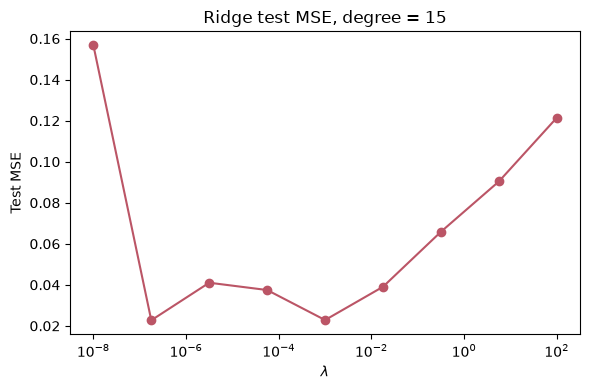

In [61]:
plt.figure(figsize=(6, 4))

plt.semilogx( lambdas,mse_ridge, "o-", color=RED)

plt.xlabel(r"$\lambda$")
plt.ylabel("Test MSE")
plt.title(f"Ridge test MSE, degree = {degree}")

plt.tight_layout()
plt.show()

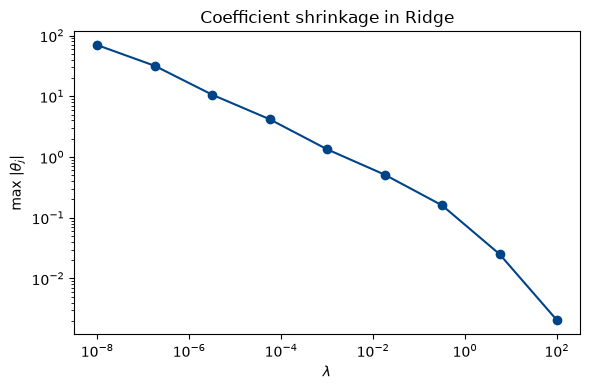

In [62]:
max_theta_ridge= np.zeros(len(lambdas))

for i, theta in enumerate(theta_ridge_all):
    max_theta_ridge[i]= np.max(np.abs(theta_ridge_all[i]))

plt.figure(figsize=(6, 4))
plt.loglog(lambdas, max_theta_ridge, "o-",color=BLUE
)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"max $|\theta_j|$")
plt.title("Coefficient shrinkage in Ridge")

plt.tight_layout()
plt.show()


In [63]:
# comparing OLS and Ridge

y_train_pred_ols , y_test_pred_ols, theta_ols= fit_predict(x_train, x_test, y_train, degree, lam=0.0)

y_train_pred_ridge, y_test_pred_ridge, theta_ridge= fit_predict(x_train, x_test, y_train, degree, lam= 0.01)

print(f"OLS: MSE = {MSE(y_test, y_test_pred_ols)}, R2 = {R2(y_test, y_test_pred_ols)}")
print(f"Ridge: MSE = {MSE(y_test, y_test_pred_ridge)}, R2 = {R2(y_test, y_test_pred_ridge)}")

print("OLS max |theta|   :", np.max(np.abs(theta_ols)))
print("Ridge max |theta| :", np.max(np.abs(theta_ridge)))

OLS: MSE = 0.18336464980949974, R2 = -0.47775866835032765
Ridge: MSE = 0.033849746768931384, R2 = 0.7272006531181436
OLS max |theta|   : 469.21920913108863
Ridge max |theta| : 0.6046401694155348


## b.3 MSE against degree, for several $\lambda$

In [67]:
lambdas_sweep = [0.0, 1e-6, 1e-4, 1e-2, 1.0]
mse_by_lambda = {}


for lam in lambdas_sweep:

    mse_deg= np.zeros(len(degrees))
    for i , deg in enumerate(degrees):
        y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, deg, lam=lam)
        mse_deg[i]= MSE(y_test, y_test_pred)

    mse_by_lambda[lam]= mse_deg



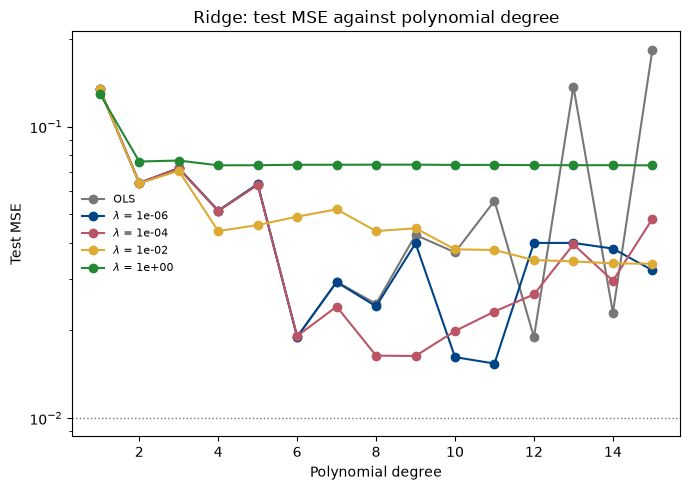

In [68]:
colors_b3 = [GREY, BLUE, RED, YELLOW, GREEN]
  
plt.figure(figsize=(7, 5))

for i, lam in enumerate(lambdas_sweep):
 
    label = "OLS" if lam == 0.0 else fr"$\lambda$ = {lam:.0e}"

    plt.semilogy(degrees, mse_by_lambda[lam], "o-", color=colors_b3[i], label=label)
  

plt.axhline(0.1**2, color=GREY, linestyle=":", linewidth=1)
  
plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.title("Ridge: test MSE against polynomial degree")
plt.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/b3_mse_degree.pdf", bbox_inches="tight")
plt.show()

## b.4 Coefficient paths

Plot $\theta_j$ against $\lambda$ (log axis). Watch every coefficient shrink smoothly
toward zero — but **never reach it exactly**. That is the difference from Lasso in
part g).

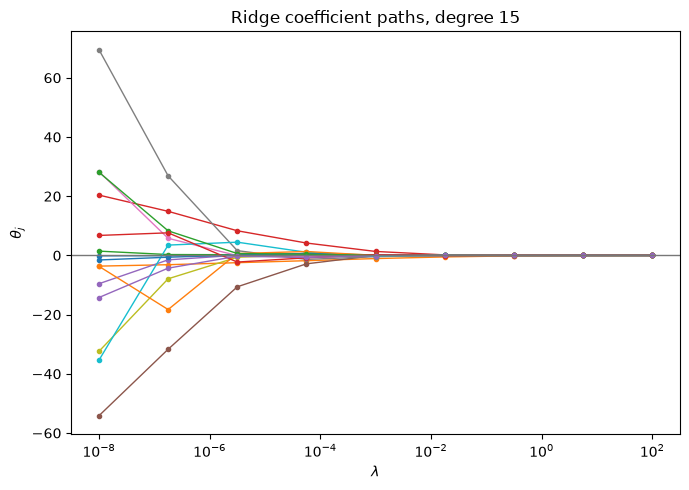

In [69]:
theta_paths = np.array(theta_ridge_all)

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas, theta_paths[:, j], "o-", linewidth=1, markersize=3)
 

plt.axhline(0, color=GREY, linewidth=1)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")
 
plt.tight_layout()
plt.savefig("../results/b4_coef_paths.pdf", bbox_inches="tight")
plt.show()
  


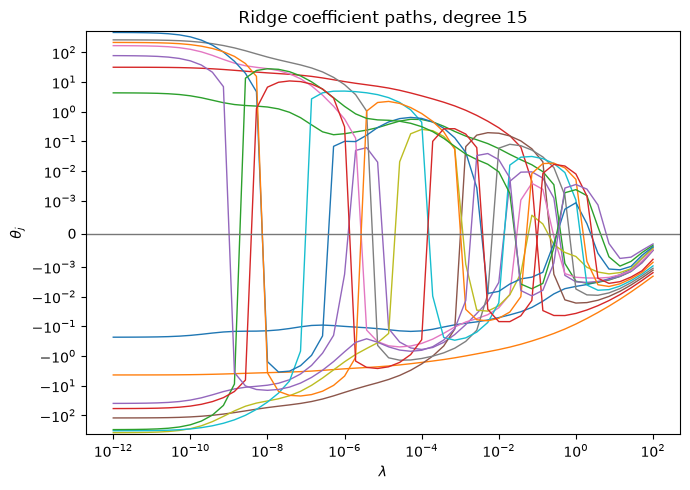

smallest |theta| at lam = 100: 0.0003029802222823352
any coefficient exactly zero: False


In [70]:
lambdas_paths = np.logspace(-12, 2, 50)

theta_paths = np.array([fit_predict(x_train, x_test, y_train, 15, lam=lam)[2]
                          for lam in lambdas_paths])

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas_paths, theta_paths[:, j], "-", linewidth=1)

plt.axhline(0, color=GREY, linewidth=1)
plt.yscale("symlog", linthresh=1e-3)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")

plt.tight_layout()
plt.savefig("../results/b4_coef_paths.pdf", bbox_inches="tight")
plt.show()

print("smallest |theta| at lam = 100:", np.min(np.abs(theta_paths[-1])))
print("any coefficient exactly zero:", np.any(theta_paths == 0))



## b.5 The SVD picture

With $X = U\Sigma V^T$, the two estimators differ only by a factor on each singular
direction:

| | coefficient on direction $j$ |
|---|---|
| OLS | $\dfrac{1}{\sigma_j}(u_j^Ty)$ |
| Ridge | $\dfrac{\sigma_j}{\sigma_j^2+\lambda}(u_j^Ty)$ |

so Ridge applies the shrinkage factor $\sigma_j^2/(\sigma_j^2+\lambda)$: directions with
large $\sigma_j$ pass through untouched, directions with small $\sigma_j$ are crushed.

Compute the singular values of your degree-15 design matrix, plot the shrinkage
factor for a few $\lambda$, and connect it to the coefficient explosion in a.4.

In [71]:
degree = 15

# Degree-15 design matrix
X_train = polynomial_features(x_train, degree)


X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std


singular_values = np.linalg.svd(X_train_scaled, compute_uv=False)

print("Singular values:")
print(singular_values)

print("\nLargest singular value :", singular_values[0])
print("Smallest singular value:", singular_values[-1])
print("Condition number       :", singular_values[0] / singular_values[-1])

Singular values:
[27.5911 18.0132  8.3101  5.9052  2.733   1.5002  0.705   0.3054  0.1289
  0.0461  0.0199  0.0053  0.0022  0.0004  0.0001]

Largest singular value : 27.591074964720246
Smallest singular value: 0.00014874894523636388
Condition number       : 185487.53351412134


In [75]:
plt.figure(figsize=(6, 4))

plt.semilogy(
    np.arange(1, len(singular_values) + 1),
    singular_values,
    "o-",
    color=BLUE
)

plt.xlabel("Singular direction")
plt.ylabel(r"$\sigma_j$")
plt.title("Singular values, degree 15")
plt.savefig("../results/b5_singular_values.pdf", bbox_inches="tight"

plt.tight_layout()
plt.show()

SyntaxError: '(' was never closed (2909898848.py, line 13)

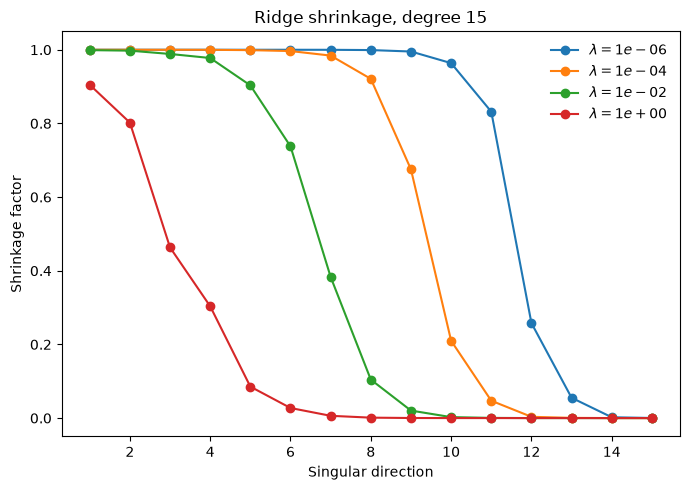

In [76]:
lambdas_svd = [1e-6, 1e-4, 1e-2, 1.0]

n_train = X_train_scaled.shape[0]

plt.figure(figsize=(7, 5))

for lam in lambdas_svd:

    shrinkage = singular_values**2 / (
        singular_values**2 + n_train * lam
    )

    plt.plot(
        np.arange(1, len(singular_values) + 1),
        shrinkage,
        "o-",
        label=fr"$\lambda={lam:.0e}$"
    )

plt.xlabel("Singular direction")
plt.ylabel("Shrinkage factor")
plt.title("Ridge shrinkage, degree 15")
plt.ylim(-0.05, 1.05)
plt.legend(frameon=False)
plt.savefig("../results/b5_shrinkage.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [77]:
print("\nShrinkage of smallest singular direction:")

for lam in lambdas_svd:

    shrinkage = singular_values**2 / (
        singular_values**2 + n_train * lam
    )

    print(
        f"lambda = {lam:.0e}  "
        f"largest direction = {shrinkage[0]:.6f}  "
        f"smallest direction = {shrinkage[-1]:.6e}"
    )


Shrinkage of smallest singular direction:
lambda = 1e-06  largest direction = 1.000000  smallest direction = 2.765016e-04
lambda = 1e-04  largest direction = 0.999989  smallest direction = 2.765773e-06
lambda = 1e-02  largest direction = 0.998950  smallest direction = 2.765781e-08
lambda = 1e+00  largest direction = 0.904905  smallest direction = 2.765781e-10


---
# Part c) Bias-variance tradeoff and the bootstrap

## Goal: Show the U-shaped test-MSE curve is just variance increasing and bias falling as the model gets complex by implementing bootstrap. Only using the OLS here.

## c.1 Train/test MSE vs complexity

Before doing the analysis, we must reproduce the Fig 2.11 of Hastie, Tibshirani and Friedman. By only doing a test/train - split and plotting the resulting MSE against the polynomial degree. Increase the max degree and use more than one value of n --> so that we get a clear U-shape.

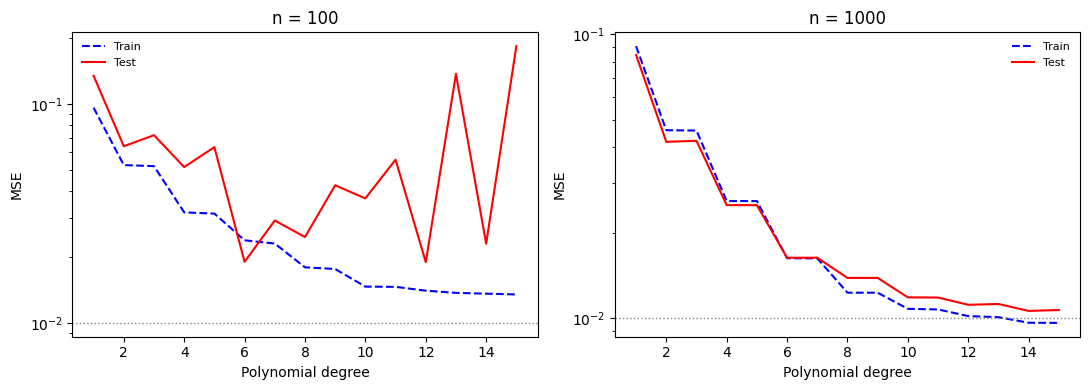

In [112]:



mse_train_by_n = {}
mse_test_by_n = {}
sigma = 0.1
#same structure as in a5
for n in n_values:
    x_n, y_n = make_data(n=n, sigma = 0.1, seed=2026)
    x_train_n , x_test_n, y_train_n, y_test_n = train_test_split(x_n,y_n, test_size = 0.2, random_state = 2026)

    mse_train = np.zeros(len(degrees))
    mse_test = np.zeros(len(degrees))

    for i, degree in enumerate(degrees):
        y_train_pred, y_test_pred, theta = fit_predict(x_train_n, x_test_n, y_train_n, degree)
        mse_train[i] = MSE(y_train_n, y_train_pred)
        mse_test[i] = MSE(y_test_n, y_test_pred)

    mse_train_by_n[n] = mse_train
    mse_test_by_n[n] = mse_test

    
#plotting
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

n_small = 100
n_large = 1000

axes[0].semilogy(degrees, mse_train_by_n[n_small], "--", color= "BLUE", label= "Train")
axes[0].semilogy(degrees,mse_test_by_n[n_small], "-", color = "RED", label = "Test")
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
axes[0].axhline(sigma**2, color="gray", linestyle=":", linewidth=1)
axes[0].set_title(f"n = {n_small}")
axes[0].legend(frameon=False, fontsize=8)

axes[1].semilogy(degrees,mse_train_by_n[n_large], "--", color = "BLUE", label = "Train")
axes[1].semilogy(degrees,mse_test_by_n[n_large], "-", color = "RED", label = "Test")
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("MSE")
axes[1].axhline(sigma**2, color="gray", linestyle=":", linewidth=1)
axes[1].set_title(f"n = {n_large}")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()




## c.2 Bootstrap: bias-variance vs degree

For each degree, resample the training set by using bootstrap. Refit to every resample and estimate: error, bias and variance.

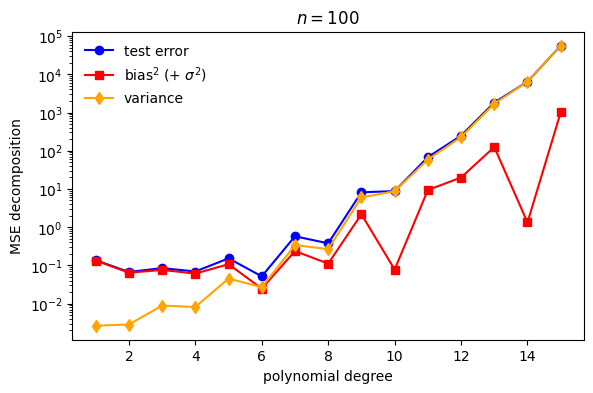

In [113]:
#c2

from sklearn.utils import resample



def bias_variance_sweep(x,y,degrees, n_bootstrap = 100, seed = 2026):
    x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = seed)
    y_test_col = y_test.reshape(-1,1) #make it a coloumn vector

    error = np.zeros(len(degrees))
    bias = np.zeros(len(degrees))
    variance = np.zeros(len(degrees))

    for idx, degree in enumerate(degrees):
        y_pred = np.empty((y_test.shape[0], n_bootstrap)) 

        for i in range(n_bootstrap):
            x_, y_ = resample(x_train,y_train, random_state = seed + i)

            #Using fit_predict from your code:

            y_train_pred, y_test_pred, theta = fit_predict(x_,x_test, y_,degree)
            y_pred[:,i] = y_test_pred

        error[idx] = np.mean(np.mean((y_test_col - y_pred)**2, axis = 1, keepdims = True))
        bias[idx] = np.mean((y_test_col - np.mean(y_pred, axis = 1, keepdims = True ))**2)
        variance[idx] = np.mean(np.var(y_pred, axis = 1, keepdims = True))

    return error, bias, variance


x_n100, y_n100 = make_data(n=100, sigma=0.1, seed=2026)
n_c2 = 100
error, bias, variance = bias_variance_sweep(x_n100,y_n100, degrees ,n_bootstrap = 100, seed = 2026)


fig, axes = plt.subplots(figsize=(6.6, 4.0))
axes.plot(degrees, error, "o-", color="blue", label="test error")
axes.plot(degrees, bias, "s-", color="red", label=r"bias$^2$ (+ $\sigma^2$)")
axes.plot(degrees, variance, "d-", color="orange", label="variance")
axes.set_yscale("log")
axes.set_xlabel("polynomial degree")
axes.set_ylabel("MSE decomposition")
axes.set_title(f"$n = {n_c2}$")
axes.legend(frameon=False)
plt.show()





## c.3 Dependence on the number of data points (n)

Reusing the c2 analysis for different values of n.

2
6
14


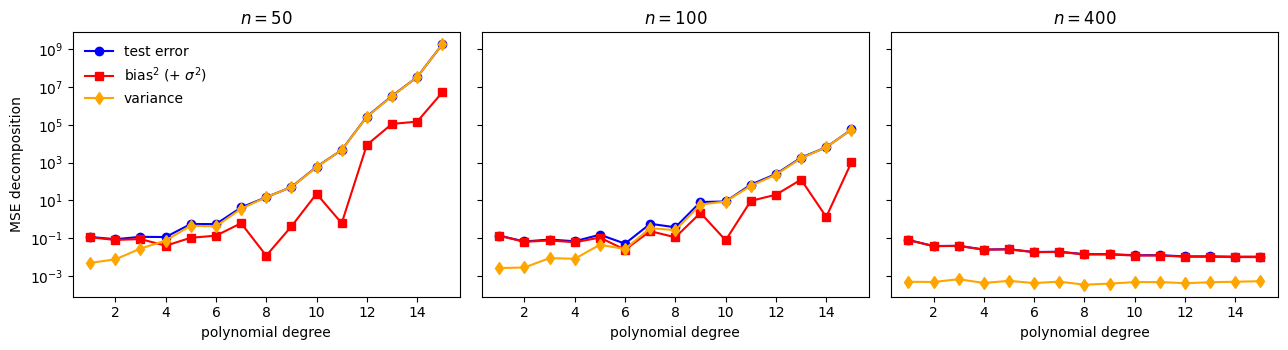

In [114]:
#c3

#Using bias_variance_sweep from c2

#Setting up our data:


n_values_c2 = [50,100,400]

# Using the function to show how it changes with different n sizes

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n in zip(axes, n_values_c2):
    x_n , y_n = make_data(n=n, sigma = 0.1, seed = 2026)
    err, b2, var = bias_variance_sweep(x_n,y_n, degrees, n_bootstrap = 100)
    print(degrees[np.argmin(err)])


    ax.plot(degrees, err, "o-", color="blue", label="test error")
    ax.plot(degrees, b2, "s-", color="red", label=r"bias$^2$ (+ $\sigma^2$)")
    ax.plot(degrees, var, "d-", color="orange", label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()



---
# Part d) Cross-validation

# Goal

Use K-fold cross-validation of sklearn and evaluate against MSE test results for OLS from a) and c), as a function of polynomoial degree, and for for Ridge as a function of both polynomial degree and lambda. Use k =5, and k = 10.

Compare the results from cross-val with the one we got from bootstrap in c)


## d.1 
Setup K-fold and cross validation, and compute OLS MSE against degrees. (same as in a) and c), but for CV )

k=5: CV selects degree 12 (CV-MSE 0.0202)
k=10: CV selects degree 12 (CV-MSE 0.0173)


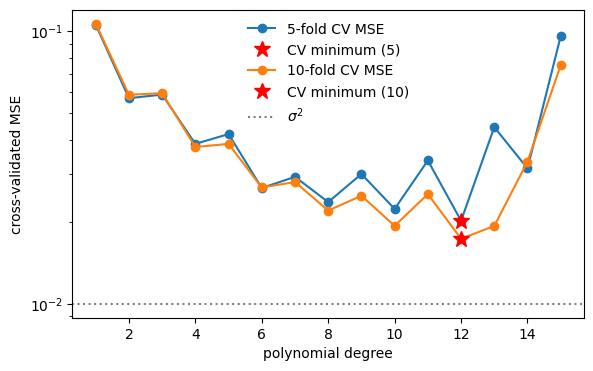

In [115]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler



n_d1 = 100

x_n,y_n = make_data(n=n_d1, sigma=0.1, seed=2026)

k_list = [5,10]
mse_cv = {}
X = x_n.reshape(-1,1)


for k in k_list:
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    mse_cv[k] = []

    for deg in degrees:
        model = make_pipeline(PolynomialFeatures(degree=deg, include_bias = False), StandardScaler(), LinearRegression(fit_intercept = True))
        scores = -cross_val_score(model, X, y_n, scoring = "neg_mean_squared_error" , cv = kfold)

        mse_cv[k].append(scores.mean())


fig, ax = plt.subplots(figsize=(6.6, 4.0))

for k in k_list:
    idx = np.argmin(mse_cv[k])
    best_deg = degrees[idx]
    print(f"k={k}: CV selects degree {best_deg} (CV-MSE {mse_cv[k][idx]:.4f})")

    ax.plot(degrees, mse_cv[k], "o-", label=f"{k}-fold CV MSE")
    ax.plot(best_deg, mse_cv[k][idx], "*", color="red", ms=12, label=f"CV minimum ({k})")

ax.axhline(0.1**2, color = "gray", linestyle = ":", label = r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.show()



Notes to the report:

**Structure**

- n = 100, sigma = 0.1, degrees = 1-15, k = 5 and k = 10, KFold(shuffle=True, random_state=2026)
- Pipeline: PolynomialFeatures(include_bias = False) #setting up the design_matrix without intercept --> StandardScaler() #every scaling is inside each fold, only training data
--> LinearRegression(fit_intercept = True) #because y is not centered in the training data, StandardScaler only scales X.
- cross_val_score, with scorinng "neg_mean_squared_error" --> take the negativ of this to get the MSE we want. Save these scores as the mean over each fold.

**Results**

- k = 5: Degree = 12, CV MSE = 0.202
- k = 10, Degree = 12, CV MSE = 0.0173
- For degree 1-3, the model is to simple --> high bias
- degree 13-15, high increase in MSE, most likely the variance ( think about result in c) )
- Seems to be a correlation between odd-numbered polynomials and a higher MSE, look at degrees: 9,11,13,15. (clearly for k = 5 )
- k = 5, and k = 10 are similar for low degrees --> at higher degrees they spread
- Everything is above the noise floor

**Questions for report**

- Why do the number of folds differ the most at higher degrees?? (number of training points? )
- What is the odd-numbered polynomial cause ?
- Can we see the bias-variance trade off?





## d.2
Doing a similar analysis as in d.1, but now we are going to use Ridge instead.

k=5: CV selects degree 11 (CV-MSE 0.0178), Best lmbda: 1.32e-06
k=10: CV selects degree 10 (CV-MSE 0.0176), Best lmbda: 8.30e-07


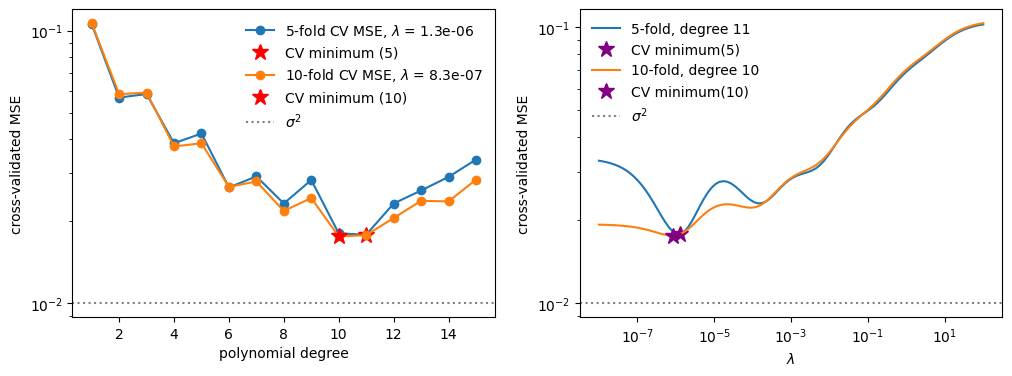

In [116]:
nlambdas = 100
lambdas = np.logspace(-8, 2, nlambdas)
ridge_cv = {}

N = len(X) 

for k in k_list:
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    ridge_cv[k] = []
    n_fold = N * (k -1) // k

    for deg in degrees:
        for lmb in lambdas:
            model = make_pipeline(PolynomialFeatures(degree=deg, include_bias = False),StandardScaler(), Ridge(alpha=n_fold*lmb))
            scores = -cross_val_score(model, X, y_n, scoring = "neg_mean_squared_error" , cv = kfold)

            ridge_cv[k].append(scores.mean())




fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 4.0))
for k in k_list:
    ridge_cv[k] = np.array(ridge_cv[k]).reshape(len(degrees), nlambdas)

    i, j = np.unravel_index(np.argmin(ridge_cv[k]), ridge_cv[k].shape)
    best_deg = degrees[i]
    best_lmb = lambdas[j]
    best_mse = ridge_cv[k][i,j]

    print(f"k={k}: CV selects degree {best_deg} (CV-MSE {best_mse:.4f}), Best lmbda: {best_lmb:.2e}")
    
    ax1.plot(degrees, ridge_cv[k][:,j], "o-", label=f"{k}-fold CV MSE, $\\lambda$ = {best_lmb:.2}")
    ax1.plot(best_deg, best_mse, "*", color="red", ms=12, label=f"CV minimum ({k})")
    ax2.plot(lambdas, ridge_cv[k][i,:], "-", label=f"{k}-fold, degree {best_deg}")
    ax2.plot(best_lmb,best_mse, "*", color="purple", ms=12, label=f"CV minimum({k})")

ax1.axhline(0.1**2, color = "gray", linestyle = ":", label = r"$\sigma^2$")
ax2.axhline(0.1**2, color = "gray", linestyle = ":", label = r"$\sigma^2$")
ax1.set_yscale("log")
ax1.set_xlabel("polynomial degree")
ax1.set_ylabel("cross-validated MSE")
ax1.legend(frameon=False)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel("cross-validated MSE")
ax2.legend(frameon = False)
plt.show()



    

Notes to the report

**Structure**
- n = 100, degrees: 1-15, noise = 0.1, lambda = logspace(-8,2,100), k = 5 and 10.
- Pipeline: PolynomialFeatures(include_bias = False) #setting up the design_matrix without intercept --> StandardScaler() #every scaling is inside each fold, only training data
--> Ridge (alpha = n_fold * lambda) # n_fold = N(k-1) /k , (80 for k = 5, 90 for k = 10 ), n_fold comes from the 1/n factor infront of the error term in the cost function (sklearn does not have this so we add it through alpha )
- Left figure is: MSE against degree for a set lmbda (best lmbda for each k )
- Right figure is: MSE against lmbda at a set degre (best degree for each k)

**Results**

- k = 5: degree 11, CV-MSE = 0.0178, lmbda = 1.32e-6
- k = 10, degree 10, CV-MSE = 0.0176, lmbda = 8.30e-7
- For lmbda ≥ 1e-3, the k=5, and k=10 are identical. They grow to the MSE of the 1st degree polynomial.
- k = 5, has a clear dump for lmbda = 1e-6, While k=10 is smooth for smallest lambda values.
- oddnumber spikes for MSE against degree still.
- We get a rise in MSE for lmda : 1e-5 - 1e-4
- above noise floor

**Questions for report**

- Why does k = 5 have a clear dip in compared to k = 10 ?
- What is this rise in MSE for lmbda 1e-5 - 1e-4 ??


## d3  Cross-val vs bootstrap

Compare cross-val from d1) to the bootstrap from c), OLS for both same data. So the difference in result comes from the resampling only.

1) do the methods point to the same complexity?
2) Answer why scaling needs to happen inside the loop for cross-val, (this is to prevent data leakage, by doing it inside the fold we have already seperated the training and test data)

Bootstrap: selectes degree 6, MSE: 0.0517
5-fold: selectes degree 12, MSE: 0.0202
10-fold: selectes degree 12, MSE: 0.0173


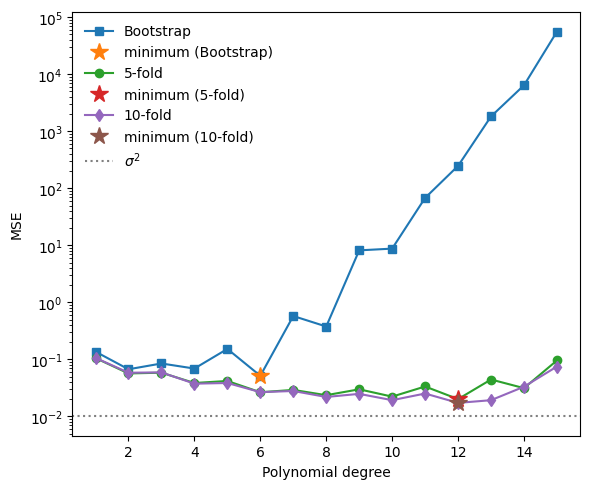

In [117]:
#setting up bootstrap from c3 with the same values as CV from d1

n_d3 = 100
x_d3, y_d3 = make_data(n=n_d3, sigma=0.1, seed=2026)
X = x_d3.reshape(-1,1)
err_boot, b2_boot, var_boot = bias_variance_sweep(x_d3,y_d3, degrees, n_bootstrap = 100)

curves = {"Bootstrap": np.array(err_boot),
          "5-fold": np.array(mse_cv[5]),
          "10-fold": np.array(mse_cv[10])
}

marks = {"Bootstrap": "s-", "5-fold": "o-", "10-fold": "d-"}


fig, ax = plt.subplots(figsize = (6.0, 5.0))

for name, mse in curves.items():
    idx = np.argmin(mse)
    print(f"{name}: selectes degree {degrees[idx]}, MSE: {mse[idx]:.4f}")

    ax.plot(degrees, mse, marks[name], label = name)
    ax.plot(degrees[idx], mse[idx], "*", ms = 13, label=f"minimum ({name})")

ax.axhline(0.1**2, color="gray", linestyle=":", label=r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.legend(frameon = False)
plt.tight_layout()
plt.show()
    





**Structure**

- Same data for both from: make_data(n=100, sigma = 0.1, seed = 2026), OLS from degrees 1-15
- Bootstrap, same as from c2, 100 bootstrap samples of the training set.
- CV, same as from d1, with k = 5 and k = 10

**Bugs found and fixed**
- resample() had no random_state → new bootstrap samples every run, not reproducible
  - same code gave best degree 6 in c3 and 2 in d3; n=400 gave 14 or 15
- random_state=2026 made all 100 samples identical (no bootstrap, variance = 0)
- Fix: random_state = seed + i → different samples per round, identical between runs
- c2, c3, d1, d3 rerun after the fix

**Results**
- Bootstrap: degree 6, MSE:  0.0517
- 5 fold: degree 12, MSE : 0.0202
- 10 fold: degree 12, MSE : 0.0173
- For degrees 1-6. The methods nearly agree, with bootstrap having the highest MSE.
- For degrees ≥ 7: We get bootstrap explotion, while CV stays low and reaches minimum at degree 12.
- The models do not point to the same complexity.

**questions for report**

- Why is CV more stable ??
- Why must scaling be done inside each fold ?
- What causes the bootstrap explotion




---
# Part e) Gradient descent, analytical and automatic gradients

---
# Part f) Momentum, AdaGrad, RMSprop and Adam

---
# Part e) Gradient descent, analytical and automatic gradients

## e.1 The analytical gradient

## e.2 Automatic differentiation with JAX

## e.3 Plain gradient descent for OLS

## e.4 The learning rate and the largest Hessian eigenvalue

## e.5 Gradient descent for Ridge

## F) momentum and adaptive learning.

**setup**

- Data from make_data, the degree should be chosen after e)
- Use the code from ex38 and tuesday37/38.




### f1
- Setting up all the methods, and the closed form, cost, gradient, hessian_eigs functions.
-  See if the methods converge to the closed form solotions for OLS and Ridge
- Plot : $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method. (ex38 2a)

In [176]:
#code from exerise38:
# setting up all the functions and methods


def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))


def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g                                 # Eq. (4.28)
        state["v"] = v
        return theta - v, state
    if method == "adagrad":    
        r = state.get("r", 0.0) + g * g                              # Eqs. (4.42) and (4.45)
        state["r"] = r 
        return theta - gamma * g /(np.sqrt(r) + eps ), state
    if method == "rmsprop":  
        r = rho * state.get("r", 0.0) + (1.0 - rho)*g*g                                # Eqs. (4.47) and (4.48)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":   
        m = beta1 * state.get("m", 0.0) + (1.0-beta1)*g
        r = beta2*state.get("r", 0.0) + (1.0-beta2)*g*g                                  # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m
        state["r"] = r 
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        return theta - gamma*m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-12, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t



def runge_data(n=100, degree=6, sigma=0.1, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    x, y = make_data(n=n, sigma = sigma, seed = seed)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered


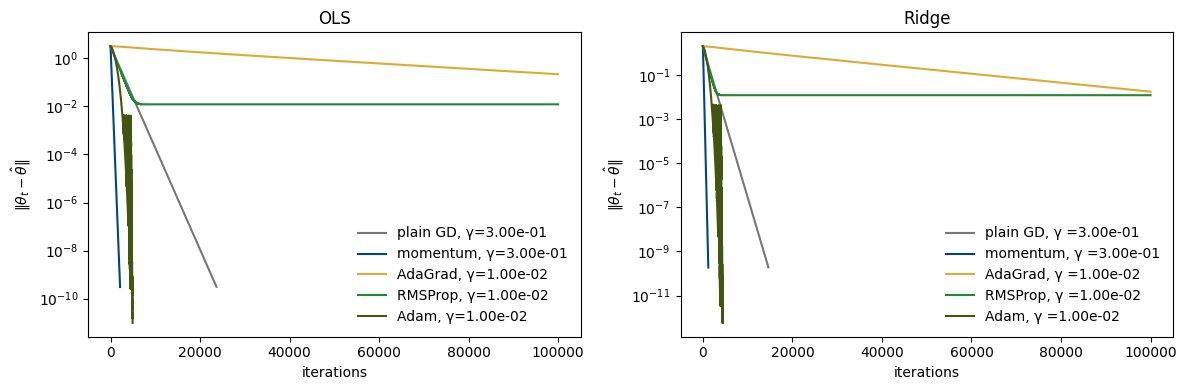

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)
#sceleton from week37tuesday


#----------------------
X_f , y_f = runge_data(degree = 6) # This can be changed after deciding what degree we look at in e)
eigf1 = hessian_eigs(X_f)
eigmin_f1 = eigf1[0]
eigmax_f1 = eigf1[-1]
gmaxf1 = 2 / eigmax_f1
#------------------------


#--------------------------
cf_OLS = closed_form(X_f,y_f)
cf_Ridge = closed_form(X_f,y_f, lam = 0.001) # we decide on a lambda after e)
#--------------------------


#Function from ex38 that fits to a specific RUNS list.
def runf1(X,y,theta_hat,lam,runs, num_iters=30000):
    grad = lambda th: gradient(th,X,y,lam)
    resultat = {}
    for method, gamma, color, label in runs:
        history, t = optimise(grad, np.zeros(X.shape[1]),method,gamma, num_iters = num_iters)
        distances = np.linalg.norm(history - theta_hat, axis = 1)
        resultat[(method,gamma)] = distances
    return resultat


#Setting up the Run list

RUN = (("plain", 0.9*gmaxf1 , "#777777", "plain GD"), ("momentum", 0.9*gmaxf1, "#004488", "momentum"),("adagrad", 0.01, "#DDAA33", "AdaGrad"), ("rmsprop", 0.01, "#228833", "RMSProp"),
       ("adam", 0.01, "#445511"  , "Adam"))

resultat_OLS = runf1(X_f,y_f,cf_OLS,0.0,RUN, num_iters = 20000)
resultat_Ridge = runf1(X_f, y_f, cf_Ridge, 0.001,RUN, num_iters = 20000)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 4.0))
for method, gamma, color, label in RUN:
    ax1.semilogy(resultat_OLS[(method, gamma)], color=color, label=f"{label}, γ={gamma:.2e}")
    ax2.semilogy(resultat_Ridge[(method,gamma)], color = color, label=f"{label}, γ ={gamma:.2e}")
ax1.set_xlabel("iterations")
ax1.set_ylabel(r"$\|\theta_t - \hat\theta\|$")
ax1.set_title("OLS")
ax2.set_title("Ridge")
ax1.legend(loc="lower right", frameon=False, fontsize=10)
ax2.set_xlabel("iterations")
ax2.set_ylabel(r"$\|\theta_t - \hat\theta\|$")
ax2.legend(loc="lower right", frameon=False, fontsize=10)
plt.tight_layout()

plt.show()





**Setup**
 - Using runge_data function to (which includes make_data ) so that we get normalized and centered data. we use degree 6 here, could change after looking at e).
 - Setting up the runf1 function to go over a the RUN tuple. In the runf1 function we call on each of the methods from optimiser step, with a temporary lambda ( choose a specific after doing e) )
 - Comparing how each of the gradient optimisers compare to the closed_form solotuins, and seeing if they converge , ( the given tolerance is inside optimise function )
 - PlainGD and momentum use 0.9*gamma_max for the given degree 

 **Results**

 - momentum, Adam, PlainGD all converge, AdaGrad would also converge it would just need a lot more iterations, RMSProp will not converge.
 - Ridge causes faster convergence than OLS



## f2

- Mak a table that shows how long each method uses to converge, make it clear wether or not it is diverging or wether it doesnt converge within our given iterations.

In [189]:
print("OLS")
for method, gamma, color, label in RUN:
    distanse = resultat_OLS[(method,gamma)]
    if (distanse < 1e-6).any():
        under = np.argmax(distanse < 1e-6)
        print(f"{label}_OLS converge, gamma = {gamma:.2e}: {under:.2e} iterations")
    else:
        print(f"{label}_OLS, gamma = {gamma}: does not converge")

print()
print("Ridge")
for method, gamma, color, label in RUN:
    distanse = resultat_Ridge[(method,gamma)]
    if (distanse < 1e-6).any():
        under = np.argmax(distanse < 1e-6)
        print(f"{label}_Ridge converge, gamma = {gamma:.2e}: {under:.2e} iterations")
    else:
        print(f"{label}_Ridge, gamma = {gamma:.2e}: does not converge")


OLS
plain GD_OLS converge, gamma = 3.00e-01: 1.54e+04 iterations
momentum_OLS converge, gamma = 3.00e-01: 1.39e+03 iterations
AdaGrad_OLS, gamma = 0.01: does not converge
RMSProp_OLS, gamma = 0.01: does not converge
Adam_OLS converge, gamma = 1.00e-02: 3.79e+03 iterations

Ridge
plain GD_Ridge converge, gamma = 3.00e-01: 9.20e+03 iterations
momentum_Ridge converge, gamma = 3.00e-01: 7.65e+02 iterations
AdaGrad_Ridge, gamma = 1.00e-02: does not converge
RMSProp_Ridge, gamma = 1.00e-02: does not converge
Adam_Ridge converge, gamma = 1.00e-02: 3.05e+03 iterations


## f3 

- Look at how the methods are dependent on the initial learning 

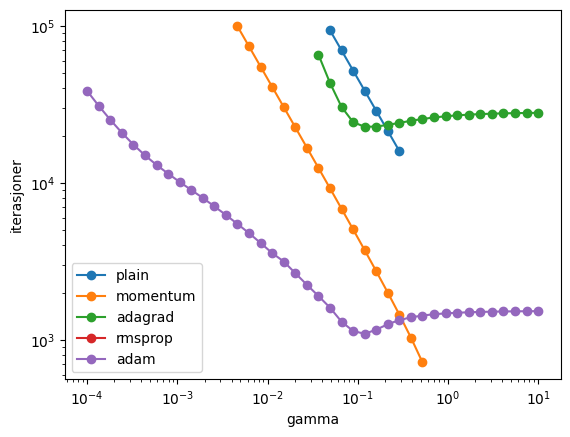

In [194]:
gammas = np.geomspace(1e-4, 10, 40)
modeller = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
theta0 = np.zeros(X_f.shape[1])
tol = 1e-6

skann = {}


with np.errstate(over="ignore", invalid="ignore"):              

    for method in modeller:
        iterasjoner = []
        for gamma in gammas:
            history, t = optimise(lambda th: gradient(th,X_f,y_f,lam=0), theta0, method ,gamma, num_iters = 100000)
            distanse = np.linalg.norm(history - cf_OLS, axis = 1 )
            if (distanse < tol).any():
                iterasjoner.append(np.argmax(distanse < tol))
            else:
                iterasjoner.append(np.nan)
            

        skann[method] = iterasjoner

fig, ax = plt.subplots()

for method in modeller:
    ax.loglog(gammas,skann[method],"o-" ,label = method)

plt.xlabel("gamma")
plt.ylabel("iterasjoner")
plt.legend()
plt.show()


---
# Part g) Lasso regression

---
# Part h) Stochastic gradient descent

---
# Part i) Final comparison: OLS, Ridge and Lasso with cross-validation

---
# Part g) Lasso regression

## g.1 The subgradient of $|\theta|$ at zero

## g.2 Lasso by gradient descent

## g.3 Benchmark against scikit-learn

## g.4 Sparsity: Lasso against Ridge

---
# Part h) Stochastic gradient descent

## h.1 Mini-batches and epochs

## h.2 Dependence on batch size and number of epochs

## h.3 Learning rate schedule

## h.4 SGD against full-batch gradient descent